1-Bibliotecas:

In [103]:
import scipy.io as io
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
import amc_mlp_pipeline as mlp_pipe
import importlib
importlib.reload(mlp_pipe) 

<module 'amc_mlp_pipeline' from 'c:\\Users\\felip\\Documents\\Mestrado-ITA\\ET-287\\ProjetoGrupo\\amc_mlp_pipeline.py'>

2-Carrega Base

In [50]:
path = r'C:\Users\felip\Documents\Mestrado-ITA\ET-287\ProjetoGrupo\dataset'

with h5py.File(os.path.join(path, 'X_train.mat'), 'r') as f:
    X_train = np.array(f['X_train'], dtype='float32').T

with h5py.File(os.path.join(path, 'X_val.mat'), 'r') as f:
    X_val = np.array(f['X_val'], dtype='float32').T

with h5py.File(os.path.join(path, 'X_test.mat'), 'r') as f:
    X_test = np.array(f['X_test'], dtype='float32').T

Y_train = io.loadmat(os.path.join(path, 'Y_train.mat'))['Y_train']
Y_val   = io.loadmat(os.path.join(path, 'Y_val.mat'))['Y_val']
Y_test  = io.loadmat(os.path.join(path, 'Y_test.mat'))['Y_test']

lbl_train = io.loadmat(os.path.join(path, 'lbl_train.mat'))['lbl_train']
lbl_val   = io.loadmat(os.path.join(path, 'lbl_val.mat'))['lbl_val']
lbl_test  = io.loadmat(os.path.join(path, 'lbl_test.mat'))['lbl_test']

In [ ]:
print("Y_train shape:", Y_train.shape)
print("Y_train[:5]:", Y_train[:5])

print("lbl_train shape:", lbl_train.shape)
print("lbl_train[:5]:", lbl_train[:5])

Y_train shape: (469200, 23)
Y_train[:5]: [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
lbl_train shape: (469200, 6)
lbl_train[:5]: [[ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  4.22743774e-03
   1.28290481e-01  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  2.00246104e-01
   7.98754715e-02  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  1.26933729e-01
   2.25750427e-01  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  6.48238329e-02
   1.46626138e-01  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  6.20988175e-02
   1.12184316e-01  0.00000000e+00]]
lbl_train valores únicos (coluna de classe, se houver): [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23.]


3-Define quais sinais modelar

In [ ]:
idx_classes_paper = [0, 4, 5, 8, 10, 11, 12, 13, 14, 21, 22]

class_names_full = ['LFM', '2FSK', '4FSK', '8FSK', 'FM_Costas', '2PSK', '4PSK', '8PSK',
                    'PM_Barker', 'PM_Huffman', 'PM_Frank', 'PM_P1', 'PM_P2', 'PM_P3',
                    'PM_P4', 'PM_Px', 'PM_ZadoffChu', 'PM_T1', 'PM_T2', 'PM_T3', 'PM_T4', 'NM', 'Noise']

classes_paper = [class_names_full[i] for i in idx_classes_paper]
print(classes_paper)

['LFM', 'FM_Costas', '2PSK', 'PM_Barker', 'PM_Frank', 'PM_P1', 'PM_P2', 'PM_P3', 'PM_P4', 'NM', 'Noise']


4-Filtra Base com Sinais Selecionados

In [80]:
y_idx_train = np.argmax(Y_train, axis=1)
y_idx_val   = np.argmax(Y_val, axis=1)
y_idx_test  = np.argmax(Y_test, axis=1)

# 1) Cria máscara para as 11 classes do paper
mask_train = np.isin(y_idx_train, idx_classes_paper)
mask_val   = np.isin(y_idx_val, idx_classes_paper)
mask_test  = np.isin(y_idx_test, idx_classes_paper)

# 2) Filtra
X_train_f, Y_train_f, lbl_train_f = X_train[mask_train], Y_train[mask_train], lbl_train[mask_train]
X_val_f,   Y_val_f,   lbl_val_f   = X_val[mask_val],     Y_val[mask_val],     lbl_val[mask_val]
X_test_f,  Y_test_f,  lbl_test_f  = X_test[mask_test],   Y_test[mask_test],   lbl_test[mask_test]

print("Treino:", X_train.shape, "->", X_train_f.shape)
print("Validação:", X_val.shape, "->", X_val_f.shape)
print("Teste:", X_test.shape, "->", X_test_f.shape)

# 3) Libera memória do que não precisa mais
import gc
del X_train, X_val, X_test, Y_train, Y_val, Y_test
gc.collect()

Treino: (469200, 1024, 2) -> (224400, 1024, 2)
Validação: (156400, 1024, 2) -> (74800, 1024, 2)
Teste: (156400, 1024, 2) -> (74800, 1024, 2)


1334

In [100]:
# Re-mapear os rótulos para 0–10
remap = {old: new for new, old in enumerate(idx_classes_paper)}

y_idx_train_f = np.array([remap[c] for c in y_idx_train[mask_train]])
y_idx_val_f   = np.array([remap[c] for c in y_idx_val[mask_val]])
y_idx_test_f  = np.array([remap[c] for c in y_idx_test[mask_test]])

# One-hot para 11 classes
from tensorflow.keras.utils import to_categorical
Y_train_f = to_categorical(y_idx_train_f, num_classes=11)
Y_val_f   = to_categorical(y_idx_val_f, num_classes=11)
Y_test_f  = to_categorical(y_idx_test_f, num_classes=11)


--- Estatísticas básicas por classe ---
Classe             Média I      Std I    Média Q      Std Q
LFM                -0.0001     0.3881     0.0002     0.3880
FM_Costas          -0.0000     0.3720     0.0010     0.3713
2PSK                0.0000     0.3882    -0.0002     0.3879
PM_Barker          -0.0070     0.3905    -0.0004     0.3878
PM_Frank            0.0024     0.3695     0.0003     0.3685
PM_P1               0.0022     0.3695     0.0001     0.3687
PM_P2              -0.0012     0.3698    -0.0007     0.3691
PM_P3               0.0023     0.3694    -0.0001     0.3683
PM_P4               0.0022     0.3693    -0.0002     0.3686
NM                  0.0002     0.3882    -0.0001     0.3881
Noise               0.0001     0.2613     0.0000     0.2613

--- Gerando gráficos de EDA ---


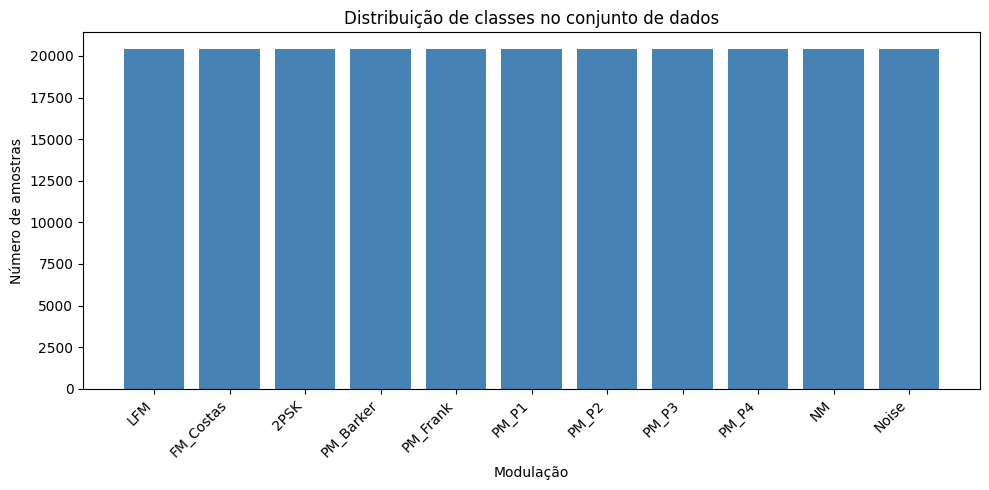

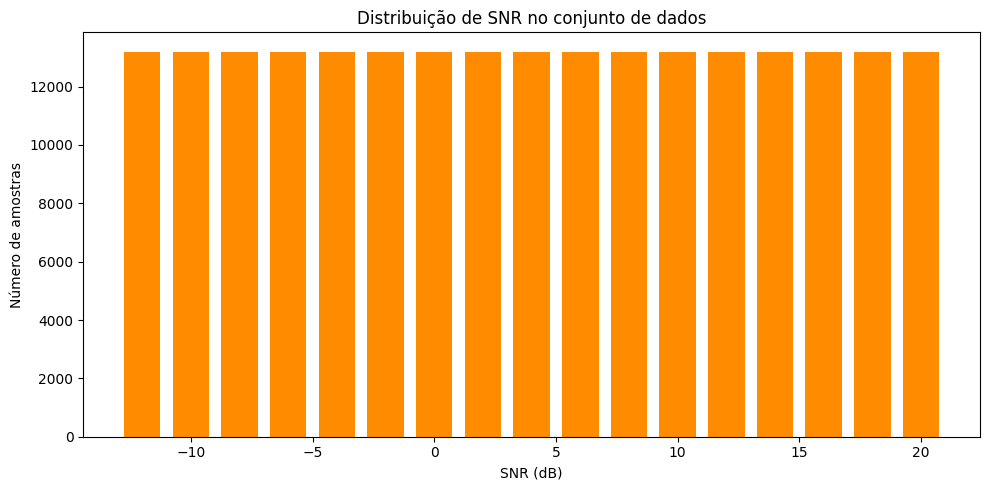

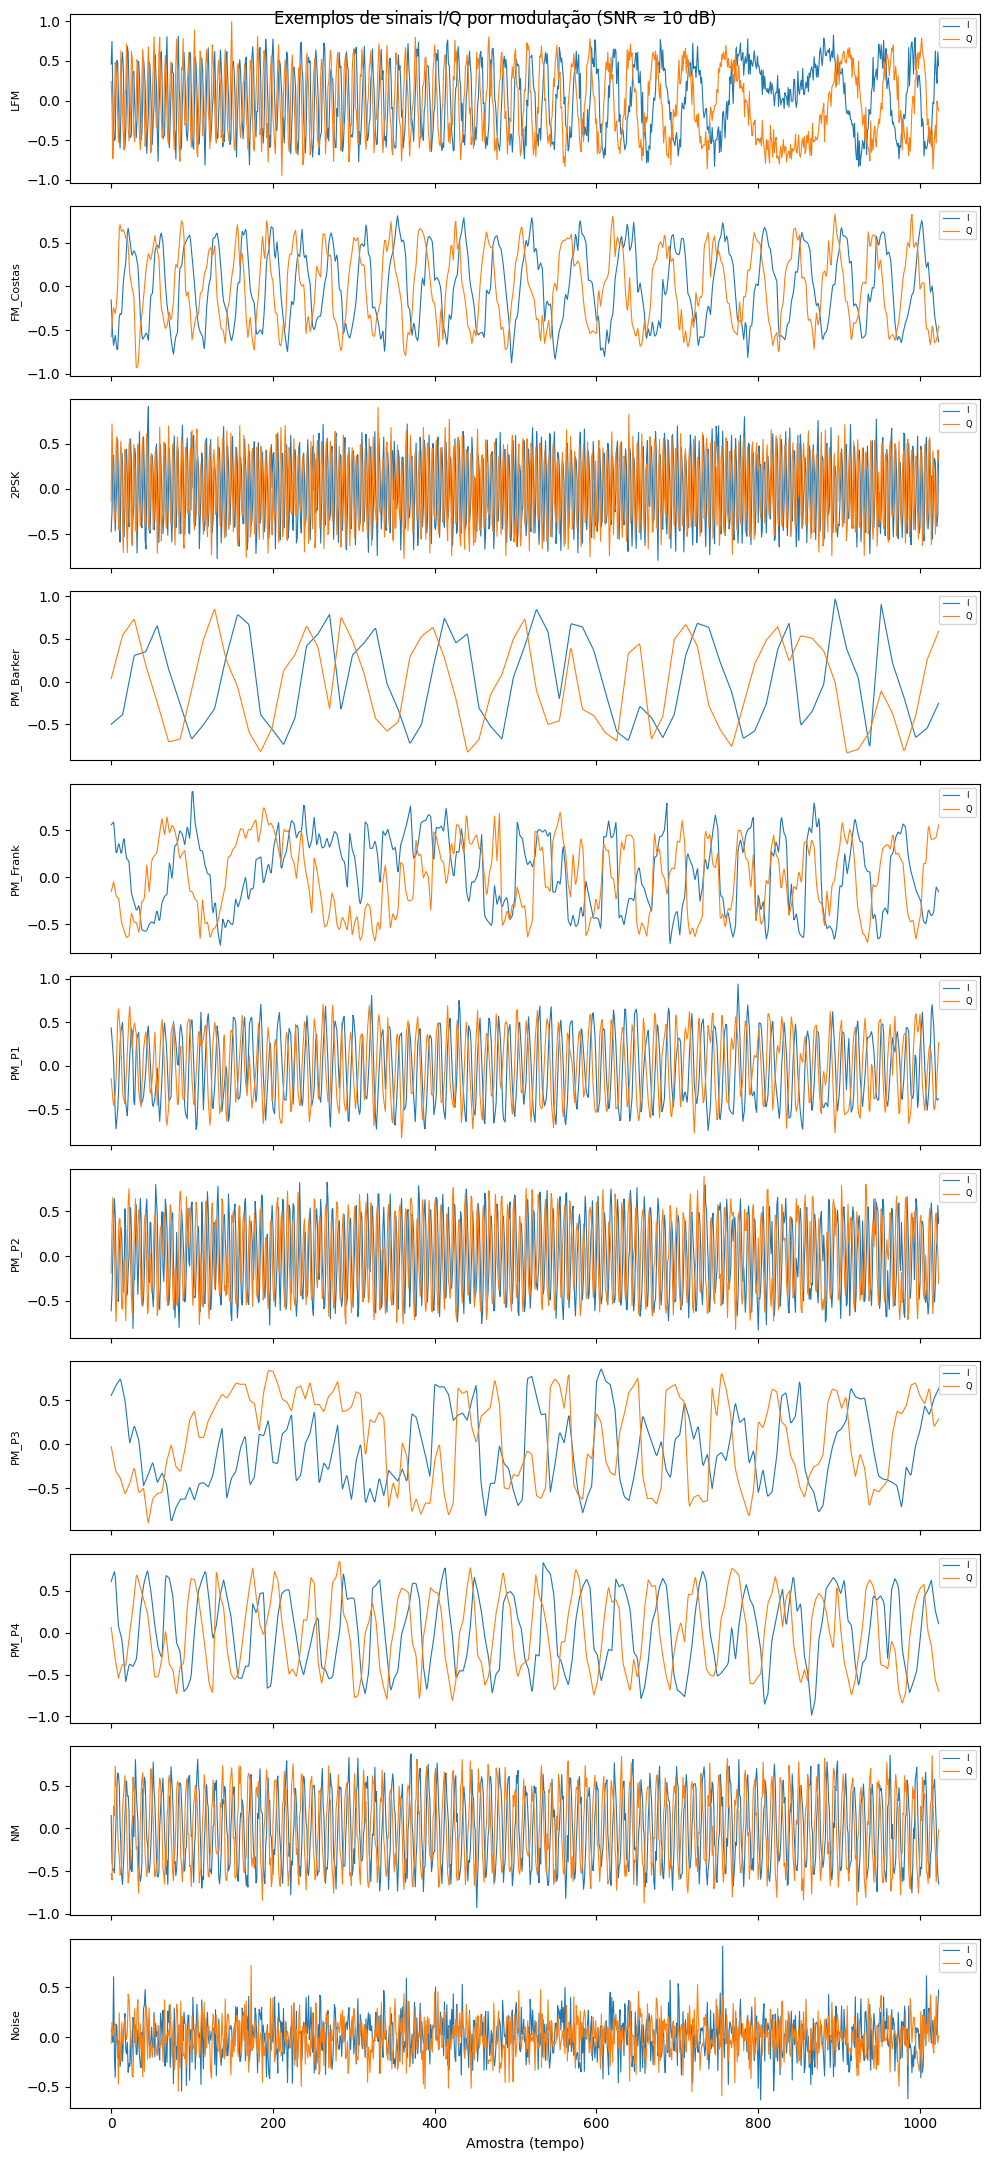

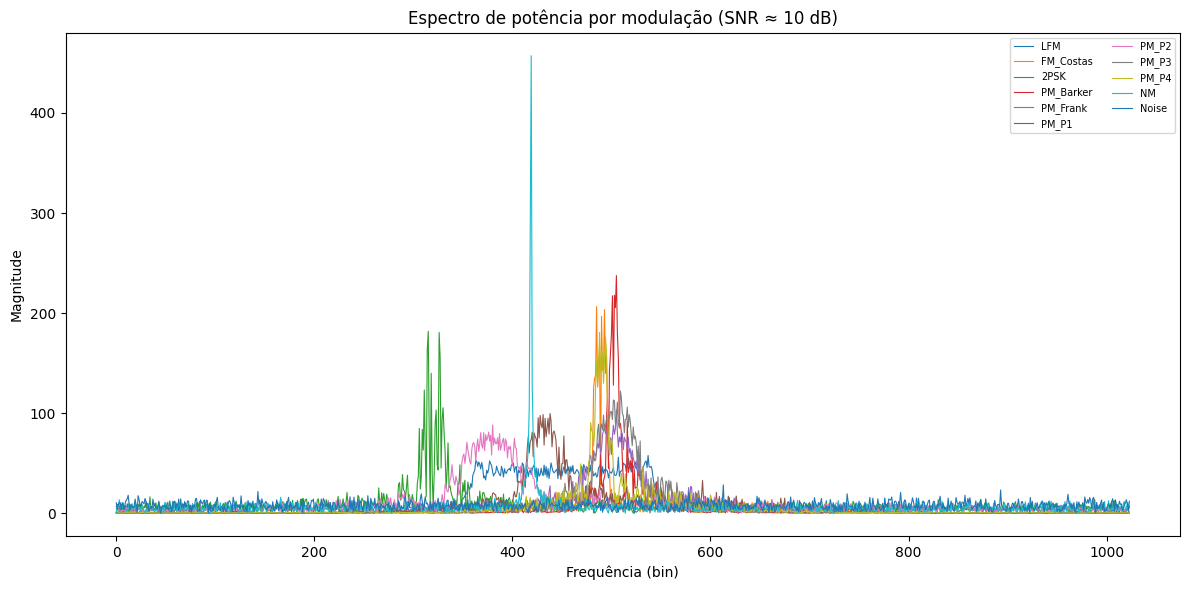

In [109]:
snr_train_f = lbl_train_f[:, 1].astype(int)

mlp_pipe.run_eda(X_train_f, y_idx_train_f, snr_train_f)

In [112]:
X_train_flat = mlp_pipe.flatten_for_mlp(X_train_f)
X_val_flat = mlp_pipe.flatten_for_mlp(X_val_f)
X_test_flat = mlp_pipe.flatten_for_mlp(X_test_f)

mean, std = mlp_pipe.compute_normalization_stats(X_train_flat)
X_train_norm = mlp_pipe.normalize(X_train_flat, mean, std)
X_val_norm = mlp_pipe.normalize(X_val_flat, mean, std)
X_test_norm = mlp_pipe.normalize(X_test_flat, mean, std)

OUTPUT_PATH = r'.\outputs'

np.save(os.path.join(OUTPUT_PATH, 'norm_mean.npy'), mean)
np.save(os.path.join(OUTPUT_PATH, 'norm_std.npy'), std)
print(f'Estatísticas de normalização salvas em {OUTPUT_PATH}')

Estatísticas de normalização salvas em .\outputs


In [114]:
print('\n=== 4. Treinando o MLP ===')
model, history = mlp_pipe.train_mlp(X_train_norm, y_idx_train_f, X_val_norm, y_idx_val_f)


=== 4. Treinando o MLP ===
Epoch 1/100
877/877 - 39s - 45ms/step - accuracy: 0.0914 - loss: 2.9645 - val_accuracy: 0.0939 - val_loss: 2.5785
Epoch 2/100
877/877 - 29s - 33ms/step - accuracy: 0.1345 - loss: 2.3897 - val_accuracy: 0.2038 - val_loss: 2.1719
Epoch 3/100
877/877 - 35s - 40ms/step - accuracy: 0.2175 - loss: 2.0632 - val_accuracy: 0.2854 - val_loss: 1.8159
Epoch 4/100
877/877 - 28s - 32ms/step - accuracy: 0.2708 - loss: 1.8574 - val_accuracy: 0.3214 - val_loss: 1.6865
Epoch 5/100
877/877 - 38s - 43ms/step - accuracy: 0.3023 - loss: 1.7360 - val_accuracy: 0.3352 - val_loss: 1.6103
Epoch 6/100
877/877 - 51s - 58ms/step - accuracy: 0.3301 - loss: 1.6447 - val_accuracy: 0.3624 - val_loss: 1.5418
Epoch 7/100
877/877 - 56s - 64ms/step - accuracy: 0.3531 - loss: 1.5729 - val_accuracy: 0.3791 - val_loss: 1.5069
Epoch 8/100
877/877 - 77s - 88ms/step - accuracy: 0.3767 - loss: 1.5122 - val_accuracy: 0.4100 - val_loss: 1.4302
Epoch 9/100
877/877 - 36s - 41ms/step - accuracy: 0.4016 - l


Acurácia geral no teste: 57.87%

              precision    recall  f1-score   support

         LFM     0.4983    0.5756    0.5342      6800
   FM_Costas     0.8401    0.6341    0.7227      6800
        2PSK     0.5260    0.6321    0.5742      6800
   PM_Barker     0.7336    0.8143    0.7718      6800
    PM_Frank     0.5100    0.5871    0.5458      6800
       PM_P1     0.3168    0.3234    0.3201      6800
       PM_P2     0.7110    0.6184    0.6615      6800
       PM_P3     0.6180    0.4528    0.5227      6800
       PM_P4     0.4066    0.5254    0.4585      6800
          NM     0.7880    0.5503    0.6480      6800
       Noise     0.6434    0.6521    0.6477      6800

    accuracy                         0.5787     74800
   macro avg     0.5992    0.5787    0.5825     74800
weighted avg     0.5992    0.5787    0.5825     74800



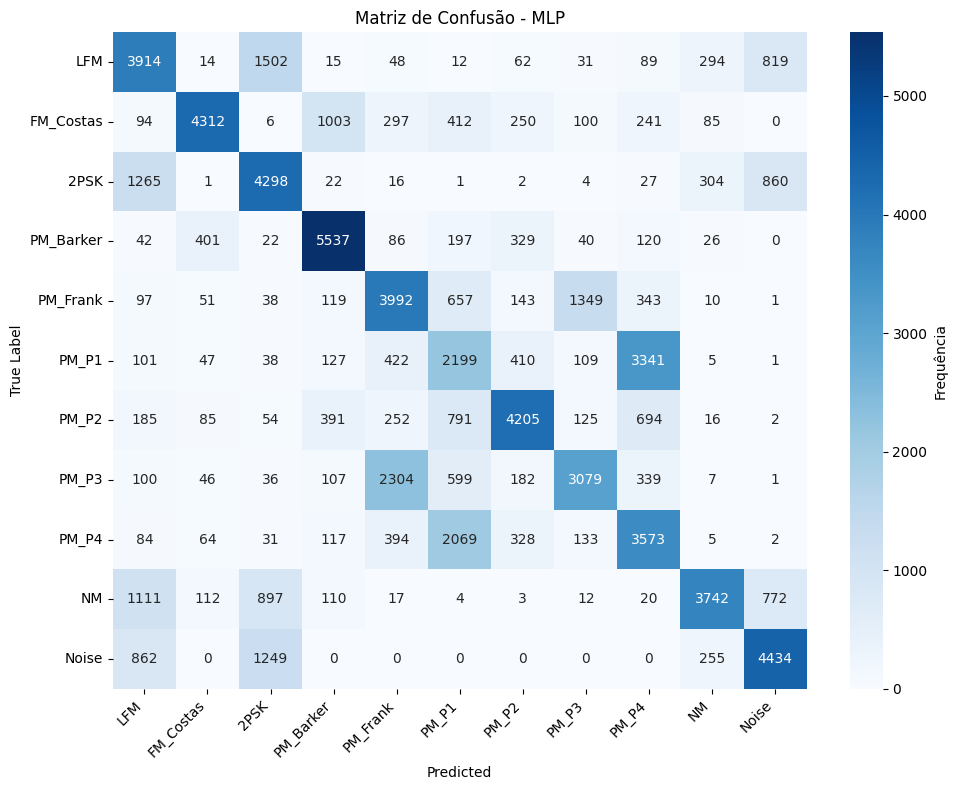

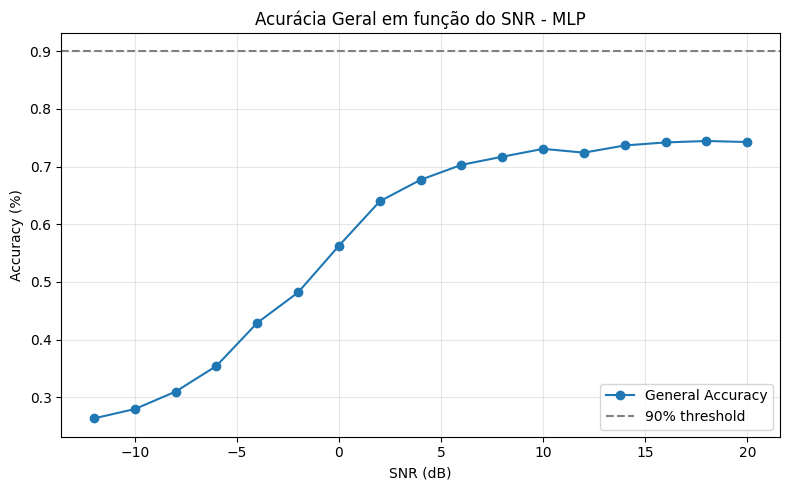

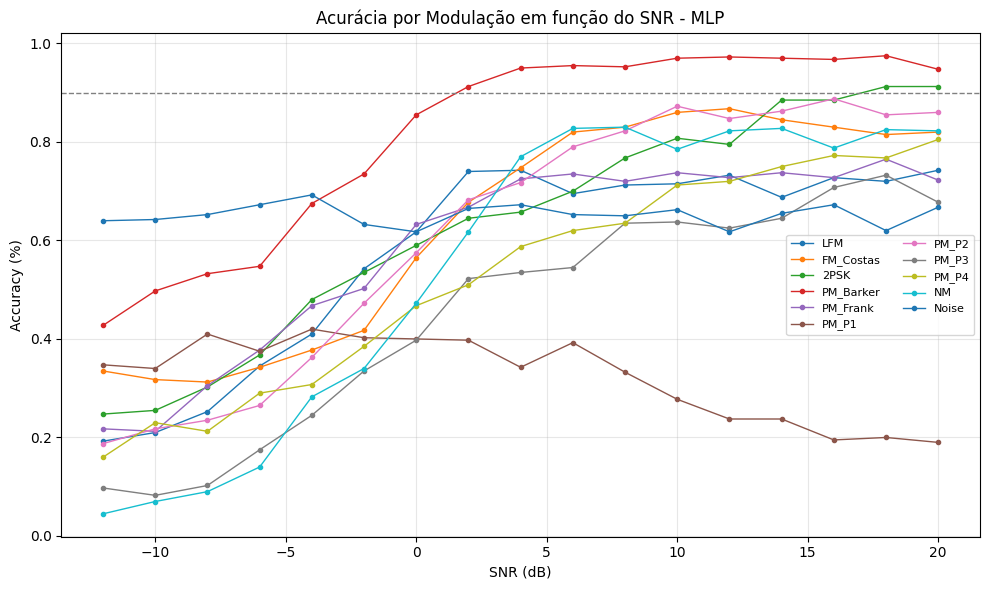


SNR mínimo (geral) para 90% de acurácia: None dB
SNR mínimo por modulação: {'LFM': None, 'FM_Costas': None, '2PSK': 18, 'PM_Barker': 2, 'PM_Frank': None, 'PM_P1': None, 'PM_P2': None, 'PM_P3': None, 'PM_P4': None, 'NM': None, 'Noise': None}
Modulação limitante: 2PSK (18 dB)


In [115]:
# 1) Achatar
X_test_flat = mlp_pipe.flatten_for_mlp(X_test_f)

# 2) Normalizar (usando mean/std calculados no TREINO - não recalcule aqui!)
X_test_norm = mlp_pipe.normalize(X_test_flat, mean, std)

# 3) SNR de teste (mesma lógica usada para o treino)
snr_test_f = lbl_test_f[:, 1].astype(int)


results = mlp_pipe.run_evaluation(model, X_test_norm, y_idx_test_f, snr_test_f)